# Notebook

this is where we have to write all of the reasonings and shit down

In [1]:
# Check is at least python 3.9
import sys 
assert (sys.version_info.major >= 3) and (sys.version_info.minor >= 9)

In [2]:
# Install required packages
!pip install wget -q
!pip install numpy -q
!pip install matplotlib -q
!pip install scikit-image -q
!pip install scikit-learn -q
!pip install pillow -q
!pip install python-mnist -q
!pip install opencv-python -q
!pip install pandas -q
!pip install tqdm -q
!pip install gdown -q

In [2]:
# Import main packages
from utils.lab_01_utils import *
from utils.lab_02_utils import *
from utils.lab_03_utils import *

from skimage.color import rgb2hsv
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects, binary_dilation

from skimage.transform import rotate, resize
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops

import cv2
import numpy as np
import pandas as pd

import os
import copy
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
from typing import Optional, Callable
from sklearn.metrics import accuracy_score, f1_score
from sklearn.covariance import LedoitWolf

In [4]:
import platform

# Get os name
os_name = platform.system().lower()

# OS X
if os_name == 'darwin':
    print("Detected OS X")
    %pip install torch torchvision torchaudio -q
    
#Windows
elif os_name == 'windows':
    print("Detected Windows")
    %pip install torch torchvision torchaudio -q
    
# Linux  
else:
    print("Detected Linux")
    %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q

Detected OS X
Note: you may need to restart the kernel to use updated packages.


## Load Dataframes

In [3]:
# get the training IDs from the image files in the data/train directory, 
# sort ascending and print the number of training and test images found

train_ids = [f.split(".")[0] for f in os.listdir("data/train_images") if f.endswith(".jpg")]
train_ids.sort()

test_ids = [f.split(".")[0] for f in os.listdir("data/test_images") if f.endswith(".jpg")]
test_ids.sort()

print(f"Found {len(train_ids)} training images and {len(test_ids)} test images.")

Found 81 training images and 159 test images.


In [7]:
# load sample submission
sample_submission = pd.read_csv("data/sample_submission.csv")

# compare image IDs in sample submission with test IDs, return non-matching IDs and print number of matches
submission_ids = sample_submission["image_id"].tolist()
non_matching_ids = [id for id in submission_ids if id not in test_ids]
print(f"{non_matching_ids} are in the sample submission but not in the test set.")

['L1000867'] are in the sample submission but not in the test set.


In [36]:
train_df = pd.read_csv("data/train.csv", sep=",")

player_cols = [c for c in train_df.columns if c.startswith("player_") and c.endswith("_cards")]

def parse_cards(x):
    return [] if x == "EMPTY" else x.split(";")

# Convert "y_4;g_2;r_3" -> ["y_4", "g_2", "r_3"]
train_df[player_cols] = train_df[player_cols].apply(lambda col: col.map(parse_cards))
train_df.head()

,image_id,center_card,active_player,player_1_cards,player_2_cards,player_3_cards,player_4_cards
0,L1000770,y_1,p3,[],"[y_4, g_2, r_3]","[r_skip, y_2, b_5]",[]
1,L1000771,r_5,p1,"[y_7, y_8, g_4]",[],"[r_9, y_0]",[]
2,L1000772,r_9,p2,"[y_8, b_6, g_3]","[b_skip, r_0, r_3]","[r_6, g_2, r_9]","[b_draw_2, y_7]"
3,L1000773,y_8,p4,"[r_1, wild, g_2]",[],"[draw_4, g_reverse, y_1]","[y_reverse, r_3]"
4,L1000774,r_4,p3,"[g_4, g_8, r_7, b_3]","[r_9, g_3]","[wild, y_3, r_8]","[b_7, b_6]"


In [37]:
# Create pandas DF for later use to predict testing data
# headings the same as the training dat
# empty for now, will be filled with predictions later

test_df = pd.DataFrame(columns=train_df.columns)
test_df.head()

# Also create train_test DF to view training data
train_test_df = pd.DataFrame(columns=train_df.columns)
train_test_df.head()


,image_id,center_card,active_player,player_1_cards,player_2_cards,player_3_cards,player_4_cards


## Display the cards and information

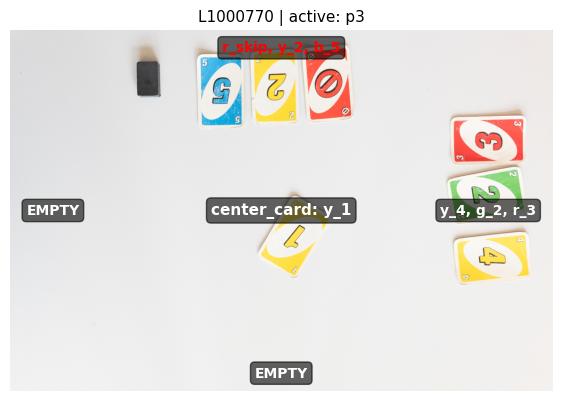

In [38]:
def display_sample(id: str, batch = "train"):
    """
    Displays a sample from the dataset with the center card and player cards annotated.
    Active player's cards are highlighted in red.
    Args:
        batch (str): "train" or "test" to specify which dataset to use.
        id (str): ID of the sample to display.
    """
    if batch == "train":
        row = train_df[train_df["image_id"] == id].iloc[0]
    elif batch == "test":
        row = test_df[test_df["image_id"] == id].iloc[0]
    else:
        raise ValueError("batch must be 'train' or 'test'")
    
    image_id = row["image_id"]
    image_path = f"data/{batch}_images/{image_id}.jpg"

    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"\nFailed to read image: {image_path}")
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    def fmt_cards(cards):
        return "EMPTY" if len(cards) == 0 else ", ".join(cards)

    active_player = row["active_player"]

    labels = {
        # Format: (x, y, ha, va) where ha=horizontalalignment, va=verticalalignment
        "player_1_cards": (0.50, 0.03, "center", "bottom"),  # bottom
        "player_2_cards": (0.97, 0.50, "right", "center"),   # right
        "player_3_cards": (0.50, 0.97, "center", "top"),     # top
        "player_4_cards": (0.03, 0.50, "left", "center"),    # left
    }

    plt.figure(figsize=(7, 7))
    ax = plt.gca()
    ax.imshow(img_rgb)
    ax.axis("off")

    # Center card in the middle
    ax.text(
        0.50, 0.50, f"center_card: {row['center_card']}",
        transform=ax.transAxes,
        ha="center", va="center",
        color="white", fontsize=11, fontweight="bold",
        bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.3")
    )

    # Player card texts around the image; active player in red
    for i, col in enumerate(player_cols, start=1):
        x, y, ha, va = labels[col]
        color = "red" if active_player == f"p{i}" else "white"
        ax.text(
            x, y, f"{fmt_cards(row[col])}",
            transform=ax.transAxes,
            ha=ha, va=va,
            color=color, fontsize=10, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.3")
        )

    plt.title(f"{image_id} | active: {active_player}", fontsize=11)
    plt.show()


# Example display first sample in the training set
display_sample(id=train_ids[0], batch="train")